In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [4]:
df = pd.read_csv('../data/cleaned_complaints.csv')
print(df.shape)
print(df[['Complaint_Category', 'Priority', 'Cleaned_Narrative']].head())

(50000, 12)
  Complaint_Category Priority  \
0   Credit Reporting     High   
1   Credit Reporting      Low   
2   Credit Reporting   Medium   
3   Credit Reporting   Medium   
4   Credit Reporting      Low   

                                   Cleaned_Narrative  
0  provisions fair credit reporting act submittin...  
1  im really sure happened mailed letters credit ...  
2  writing dispute following accounts owe debt be...  
3  pulled copy credit report noticed personal inf...  
4  inquiries matter public record accurate equifa...  


In [5]:

print(f"NaN count: {df['Cleaned_Narrative'].isna().sum()}")
print(f"Empty string count: {(df['Cleaned_Narrative'] == '').sum()}")

NaN count: 3
Empty string count: 0


In [6]:
df['Cleaned_Narrative'] = df['Cleaned_Narrative'].fillna('unknown')
df['Cleaned_Narrative'] = df['Cleaned_Narrative'].replace('', 'unknown')


In [7]:
print("Fixed. Re-checking...")
print(f"NaN count after fix: {df['Cleaned_Narrative'].isna().sum()}")

Fixed. Re-checking...
NaN count after fix: 0


In [8]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(df['Cleaned_Narrative'])
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (50000, 10000)


In [9]:
y_category = df['Complaint_Category']
y_priority = df['Priority']


X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X, y_category, test_size=0.2, random_state=42, stratify=y_category
)


X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print(f"Category — Train: {X_train_cat.shape}, Test: {X_test_cat.shape}")
print(f"Priority  — Train: {X_train_pri.shape}, Test: {X_test_pri.shape}")

Category — Train: (40000, 10000), Test: (10000, 10000)
Priority  — Train: (40000, 10000), Test: (10000, 10000)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("Training Category Classifier...")
cat_model = LogisticRegression(max_iter=1000, random_state=42)
cat_model.fit(X_train_cat, y_train_cat)

y_pred_cat = cat_model.predict(X_test_cat)

print("\n=== CATEGORY MODEL RESULTS ===")
print(classification_report(y_test_cat, y_pred_cat))

Training Category Classifier...

=== CATEGORY MODEL RESULTS ===
                            precision    recall  f1-score   support

Bank Accounts and Services       0.88      0.90      0.89      2000
      Credit Card Services       0.84      0.81      0.83      2000
          Credit Reporting       0.83      0.84      0.83      2000
           Debt Collection       0.82      0.81      0.82      2000
                     Loans       0.88      0.89      0.89      2000

                  accuracy                           0.85     10000
                 macro avg       0.85      0.85      0.85     10000
              weighted avg       0.85      0.85      0.85     10000



In [11]:
print("Training Priority Classifier...")
pri_model = LogisticRegression(max_iter=1000, random_state=42)
pri_model.fit(X_train_pri, y_train_pri)

y_pred_pri = pri_model.predict(X_test_pri)

print("\n=== PRIORITY MODEL RESULTS ===")
print(classification_report(y_test_pri, y_pred_pri))

Training Priority Classifier...

=== PRIORITY MODEL RESULTS ===
              precision    recall  f1-score   support

        High       0.92      0.93      0.92      5054
         Low       0.85      0.95      0.90      3208
      Medium       0.91      0.68      0.78      1738

    accuracy                           0.89     10000
   macro avg       0.89      0.85      0.86     10000
weighted avg       0.89      0.89      0.89     10000



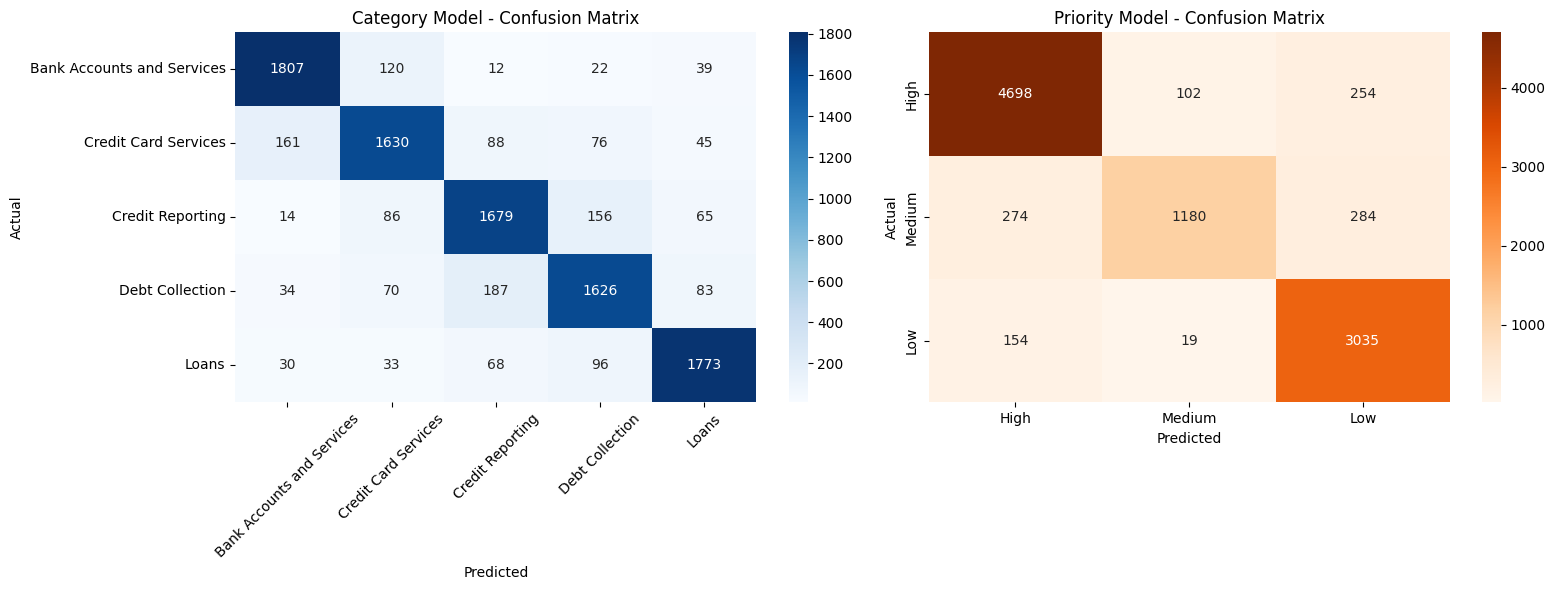

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


cm_cat = confusion_matrix(y_test_cat, y_pred_cat)
sns.heatmap(cm_cat, annot=True, fmt='d', ax=axes[0],
            xticklabels=cat_model.classes_,
            yticklabels=cat_model.classes_,
            cmap='Blues')
axes[0].set_title('Category Model - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)


cm_pri = confusion_matrix(y_test_pri, y_pred_pri,
                          labels=['High', 'Medium', 'Low'])
sns.heatmap(cm_pri, annot=True, fmt='d', ax=axes[1],
            xticklabels=['High', 'Medium', 'Low'],
            yticklabels=['High', 'Medium', 'Low'],
            cmap='Oranges')
axes[1].set_title('Priority Model - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import pickle
import os

os.makedirs('../models', exist_ok=True)


with open('../models/category_model.pkl', 'wb') as f:
    pickle.dump(cat_model, f)


with open('../models/priority_model.pkl', 'wb') as f:
    pickle.dump(pri_model, f)


with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("All models saved successfully.")

All models saved successfully.
